In [24]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
df = pd.read_excel(r"../data/raw/beds24_bookings_2016_2026.xlsx")


In [3]:
df.head()

,id,masterId,propertyId,roomId,unitId,roomQty,offerId,status,subStatus,arrival,departure,numAdult,numChild,title,firstName,lastName,email,phone,mobile,fax,company,address,city,state,postcode,country,country2,arrivalTime,voucher,comments,notes,message,groupNote,custom1,custom2,custom3,custom4,custom5,custom6,custom7,custom8,custom9,custom10,flagColor,flagText,statusCode,lang,referer,refererEditable,reference,channel,apiSourceId,apiSource,apiReference,allowChannelUpdate,allowAutoAction,allowReview,allowCancellation,invoiceeId,bookingTime,modifiedTime,cancelTime,price,deposit,tax,commission,rateDescription,stripeToken,pcibookingToken,apiMessage
0,37134772,NaN,163277,359135,5,1,1,confirmed,none,2022-12-31,2023-01-04,2,0,NaN,Ruslan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ff7f00,Departed,0,en,kaluku,kaluku,NaN,direct,0,Direct,NaN,all,enable,default,{'type': 'propertyDefault'},NaN,2022-12-31T08:12:51Z,2023-01-18T00:31:12Z,NaN,2300000.0,0,0,0.0,"Offer 1, \r\n2022-12-31 1150000 rate 3884186, ...",NaN,NaN,NaN
1,37133836,NaN,158986,350455,7,1,1,confirmed,none,2022-12-31,2023-01-01,2,0,NaN,Mr,Eza,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,en,abamsgiliair,abamsgiliair,NaN,direct,0,Direct,NaN,all,enable,default,{'type': 'propertyDefault'},NaN,2022-12-31T06:27:12Z,2023-01-15T00:31:21Z,NaN,350000.0,0,0,0.0,350000.00 per malam,NaN,NaN,NaN
2,37133826,NaN,158986,350455,1,1,1,confirmed,none,2022-12-31,2023-01-01,2,0,NaN,Mr,Eza,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,en,abamsgiliair,abamsgiliair,NaN,direct,0,Direct,NaN,all,enable,default,{'type': 'propertyDefault'},NaN,2022-12-31T06:26:06Z,2023-01-15T00:31:21Z,NaN,350000.0,0,0,0.0,350000.00 per malam,NaN,NaN,NaN
3,37115929,NaN,158986,350455,6,1,0,confirmed,none,2022-12-30,2023-01-02,2,0,NaN,Reese,Parrott,rparro.915725@guest.booking.com,+62 2035640799,NaN,NaN,NaN,"30 08 Prudential Tower, 19 Cecil St",bangkok,NaN,NaN,id,ID,NaN,NaN,** THIS RESERVATION HAS BEEN PRE-PAID **\nLarg...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,Booking.com,Booking.com,NaN,booking,19,Booking.com,3918534202,all,enable,default,{'type': 'propertyDefault'},NaN,2022-12-30T11:27:43Z,2023-01-16T00:31:46Z,NaN,1428030.0,0,0,289890.0,2022-12-30 Rate (30739057 Standard Flexible re...,NaN,NaN,NaN
4,37112201,NaN,179195,388813,1,1,0,confirmed,none,2022-12-31,2023-01-03,1,0,NaN,Annalisa,Giampietro,agiamp.692066@guest.booking.com,+62 878 6519 1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,id,ID,NaN,NaN,Approximate time of arrival: between 12:00 and...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,Booking.com,Booking.com,NaN,booking,19,Booking.com,2668644866,all,enable,default,{'type': 'propertyDefault'},NaN,2022-12-30T08:28:43Z,2023-01-17T00:31:11Z,NaN,2341750.0,0,0,421515.0,2022-12-31 Rate (1450640 Standard Rate rewritt...,NaN,NaN,NaN


In [15]:
# Filter booking.com doang channelnya
filt_channel = (df['channel'] == 'booking')
df = df[filt_channel]

In [16]:
(df.head()['channel'] == 'booking')

3    True
4    True
5    True
8    True
9    True
Name: channel, dtype: bool

In [17]:
df.columns

Index(['id', 'masterId', 'propertyId', 'roomId', 'unitId', 'roomQty',
       'offerId', 'status', 'subStatus', 'arrival', 'departure', 'numAdult',
       'numChild', 'title', 'firstName', 'lastName', 'email', 'phone',
       'mobile', 'fax', 'company', 'address', 'city', 'state', 'postcode',
       'country', 'country2', 'arrivalTime', 'voucher', 'comments', 'notes',
       'message', 'groupNote', 'custom1', 'custom2', 'custom3', 'custom4',
       'custom5', 'custom6', 'custom7', 'custom8', 'custom9', 'custom10',
       'flagColor', 'flagText', 'statusCode', 'lang', 'referer',
       'refererEditable', 'reference', 'channel', 'apiSourceId', 'apiSource',
       'apiReference', 'allowChannelUpdate', 'allowAutoAction', 'allowReview',
       'allowCancellation', 'invoiceeId', 'bookingTime', 'modifiedTime',
       'cancelTime', 'price', 'deposit', 'tax', 'commission',
       'rateDescription', 'stripeToken', 'pcibookingToken', 'apiMessage'],
      dtype='object')

In [18]:
len(df)

346847

In [19]:
print(df.isna().sum()/len(df))

id                    0.000000
masterId              0.825894
propertyId            0.000000
roomId                0.000000
unitId                0.000000
roomQty               0.000000
offerId               0.000000
status                0.000000
subStatus             0.000000
arrival               0.000000
departure             0.000000
numAdult              0.000000
numChild              0.000000
title                 0.999758
firstName             0.000081
lastName              0.000848
email                 0.012190
phone                 0.012230
mobile                1.000000
fax                   1.000000
company               1.000000
address               0.815936
city                  0.304907
state                 1.000000
postcode              0.940821
country               0.012190
country2              0.012795
arrivalTime           0.999919
voucher               0.999960
comments              0.012190
notes                 0.913374
message               1.000000
groupNot

In [21]:
# Setting the 'Datetime' column as the index of the DataFrame
df = df.set_index('arrival')

# Ensuring that the index is of datetime type
df.index = pd.to_datetime(df.index)

# Generating descriptive statistics of the DataFrame
df.describe()

,id,masterId,propertyId,roomId,unitId,roomQty,offerId,numAdult,numChild,company,state,message,custom2,custom3,custom4,custom5,custom6,custom7,custom8,custom9,custom10,statusCode,apiSourceId,invoiceeId,price,deposit,tax,commission,stripeToken,pcibookingToken
count,3.468470e+05,6.038800e+04,346847.000000,346847.000000,346847.000000,346847.0,346847.0,346847.000000,346847.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,346847.000000,346847.0,0.0,3.468470e+05,346847.0,346847.000000,3.468470e+05,0.0,0.0
mean,5.679576e+07,5.761448e+07,177520.289788,391672.174230,3.190839,1.0,0.0,1.744544,0.077014,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004036,19.0,NaN,2.079082e+06,0.0,1.630367,3.906579e+05,NaN,NaN
std,1.290581e+07,1.315755e+07,21429.136085,43888.458694,2.385453,0.0,0.0,0.717779,0.293150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.133508,0.0,NaN,1.909641e+06,0.0,256.615134,3.721640e+05,NaN,NaN
min,3.101578e+07,3.173108e+07,158986.000000,350455.000000,0.000000,1.0,0.0,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,19.0,NaN,0.000000e+00,0.0,0.000000,0.000000e+00,NaN,NaN
25%,4.620865e+07,4.720783e+07,161014.000000,354683.000000,1.000000,1.0,0.0,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,19.0,NaN,7.920000e+05,0.0,0.000000,1.425000e+05,NaN,NaN
50%,5.601984e+07,5.669863e+07,163277.000000,381255.000000,3.000000,1.0,0.0,2.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,19.0,NaN,1.530000e+06,0.0,0.000000,2.840400e+05,NaN,NaN
75%,6.779567e+07,6.822826e+07,193394.000000,419105.000000,4.000000,1.0,0.0,2.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,19.0,NaN,2.760116e+06,0.0,0.000000,5.189490e+05,NaN,NaN
max,8.144071e+07,8.142458e+07,243134.000000,622210.000000,13.000000,1.0,0.0,10.000000,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.000000,19.0,NaN,3.266941e+07,0.0,40392.000000,4.900411e+06,NaN,NaN


In [30]:
df.sort_index(inplace=True)

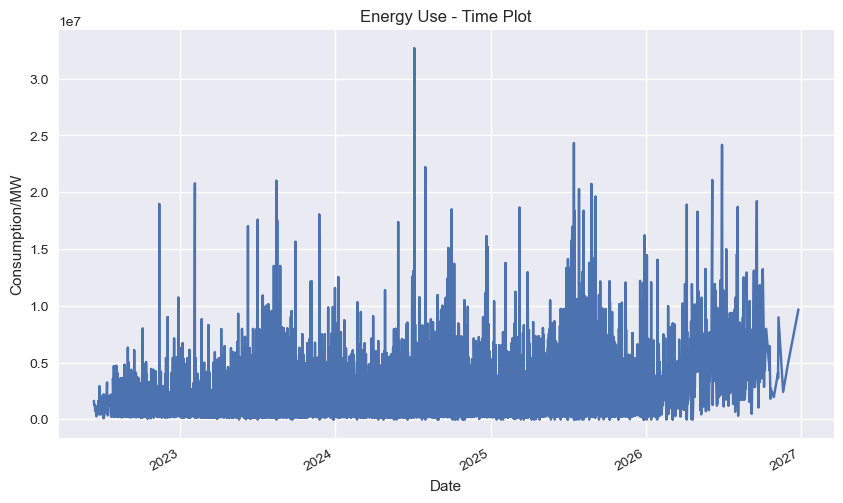

In [31]:
# Setting pyplot style
plt.style.use("seaborn-v0_8")

# Plotting time series
plt.figure(figsize=(10,6))
df['price'].plot(title='Energy Use - Time Plot')
plt.ylabel('Consumption/MW')
plt.xlabel('Date')
plt.show()

In [32]:
# Extracting time-related features

df['year'] = df.index.year
df['month'] = df.index.month
df.reset_index(inplace=True)
df['week'] = df['arrival'].dt.isocalendar().week
df['hour'] = df['arrival'].dt.hour
df['day'] = df['arrival'].dt.dayofweek
df['day_str'] = df['arrival'].dt.strftime('%a')
df['year_month'] = df['arrival'].dt.strftime('%Y_%m')
df.set_index('arrival', inplace=True)

In [33]:
df.head()

,id,masterId,propertyId,roomId,unitId,roomQty,offerId,status,subStatus,departure,numAdult,numChild,title,firstName,lastName,email,phone,mobile,fax,company,address,city,state,postcode,country,country2,arrivalTime,voucher,comments,notes,message,groupNote,custom1,custom2,custom3,custom4,custom5,custom6,custom7,custom8,custom9,custom10,flagColor,flagText,statusCode,lang,referer,refererEditable,reference,channel,apiSourceId,apiSource,apiReference,allowChannelUpdate,allowAutoAction,allowReview,allowCancellation,invoiceeId,bookingTime,modifiedTime,cancelTime,price,deposit,tax,commission,rateDescription,stripeToken,pcibookingToken,apiMessage,year,month,week,hour,day,day_str,year_month
arrival,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-06-11,31705234,NaN,161014,354683,3,1,0,confirmed,none,2022-06-15,2,0,NaN,SANGJIN,PARK,spark.204982@guest.booking.com,+62 2035640799,NaN,NaN,NaN,"30 08 Prudential Tower, 19 Cecil St",bangkok,NaN,N&#47;A,id,ID,NaN,NaN,"LargeBed, NonSmoke AdditionalNotes: High floor...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0000ff,Paid,0,NaN,Booking.com,Booking.com,NaN,booking,19,Booking.com,3247470854,all,enable,default,{'type': 'propertyDefault'},NaN,2022-06-10T03:53:02Z,2022-06-29T00:31:27Z,NaN,1620000.0,0,0,291600.0,2022-06-11 Rate (16464056 Standard Rate rewrit...,NaN,NaN,NaN,2022,6,23,0,5,Sat,2022_06
2022-06-11,31705234,NaN,161014,354683,3,1,0,confirmed,none,2022-06-15,2,0,NaN,SANGJIN,PARK,spark.204982@guest.booking.com,+62 2035640799,NaN,NaN,NaN,"30 08 Prudential Tower, 19 Cecil St",bangkok,NaN,N&#47;A,id,ID,NaN,NaN,"LargeBed, NonSmoke AdditionalNotes: High floor...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0000ff,Paid,0,NaN,Booking.com,Booking.com,NaN,booking,19,Booking.com,3247470854,all,enable,default,{'type': 'propertyDefault'},NaN,2022-06-10T03:53:02Z,2022-06-29T00:31:27Z,NaN,1620000.0,0,0,291600.0,2022-06-11 Rate (16464056 Standard Rate rewrit...,NaN,NaN,NaN,2022,6,23,0,5,Sat,2022_06
2022-06-11,31705234,NaN,161014,354683,3,1,0,confirmed,none,2022-06-15,2,0,NaN,SANGJIN,PARK,spark.204982@guest.booking.com,+62 2035640799,NaN,NaN,NaN,"30 08 Prudential Tower, 19 Cecil St",bangkok,NaN,N&#47;A,id,ID,NaN,NaN,"LargeBed, NonSmoke AdditionalNotes: High floor...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0000ff,Paid,0,NaN,Booking.com,Booking.com,NaN,booking,19,Booking.com,3247470854,all,enable,default,{'type': 'propertyDefault'},NaN,2022-06-10T03:53:02Z,2022-06-29T00:31:27Z,NaN,1620000.0,0,0,291600.0,2022-06-11 Rate (16464056 Standard Rate rewrit...,NaN,NaN,NaN,2022,6,23,0,5,Sat,2022_06
2022-06-11,31705234,NaN,161014,354683,3,1,0,confirmed,none,2022-06-15,2,0,NaN,SANGJIN,PARK,spark.204982@guest.booking.com,+62 2035640799,NaN,NaN,NaN,"30 08 Prudential Tower, 19 Cecil St",bangkok,NaN,N&#47;A,id,ID,NaN,NaN,"LargeBed, NonSmoke AdditionalNotes: High floor...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0000ff,Paid,0,NaN,Booking.com,Booking.com,NaN,booking,19,Booking.com,3247470854,all,enable,default,{'type': 'propertyDefault'},NaN,2022-06-10T03:53:02Z,2022-06-29T00:31:27Z,NaN,1620000.0,0,0,291600.0,2022-06-11 Rate (16464056 Standard Rate rewrit...,NaN,NaN,NaN,2022,6,23,0,5,Sat,2022_06
2022-06-11,31705234,NaN,161014,354683,3,1,0,confirmed,none,2022-06-15,2,0,NaN,SANGJIN,PARK,spark.204982@guest.booking.com,+62 2035640799,NaN,NaN,NaN,"30 08 Prudential Tower, 19 Cecil St",bangkok,NaN,N&#47;A,id,ID,NaN,NaN,"LargeBed, NonSmoke AdditionalNotes: High floor...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0000ff,Paid,0,NaN,Booking.com,Booking.com,NaN,booking,19,Booking.com,3247470854,all,enable,default,{'type': 'propertyDefault'},NaN,2022-06-10T03:53:02Z,2022-06-29T00:31:27Z,NaN,1620000.0,0,0,291600.0,2022-06-11 Rate (16464056 Standard Rate rewrit...,NaN,NaN,NaN,2022,6,23,0,5,Sat,2022_06


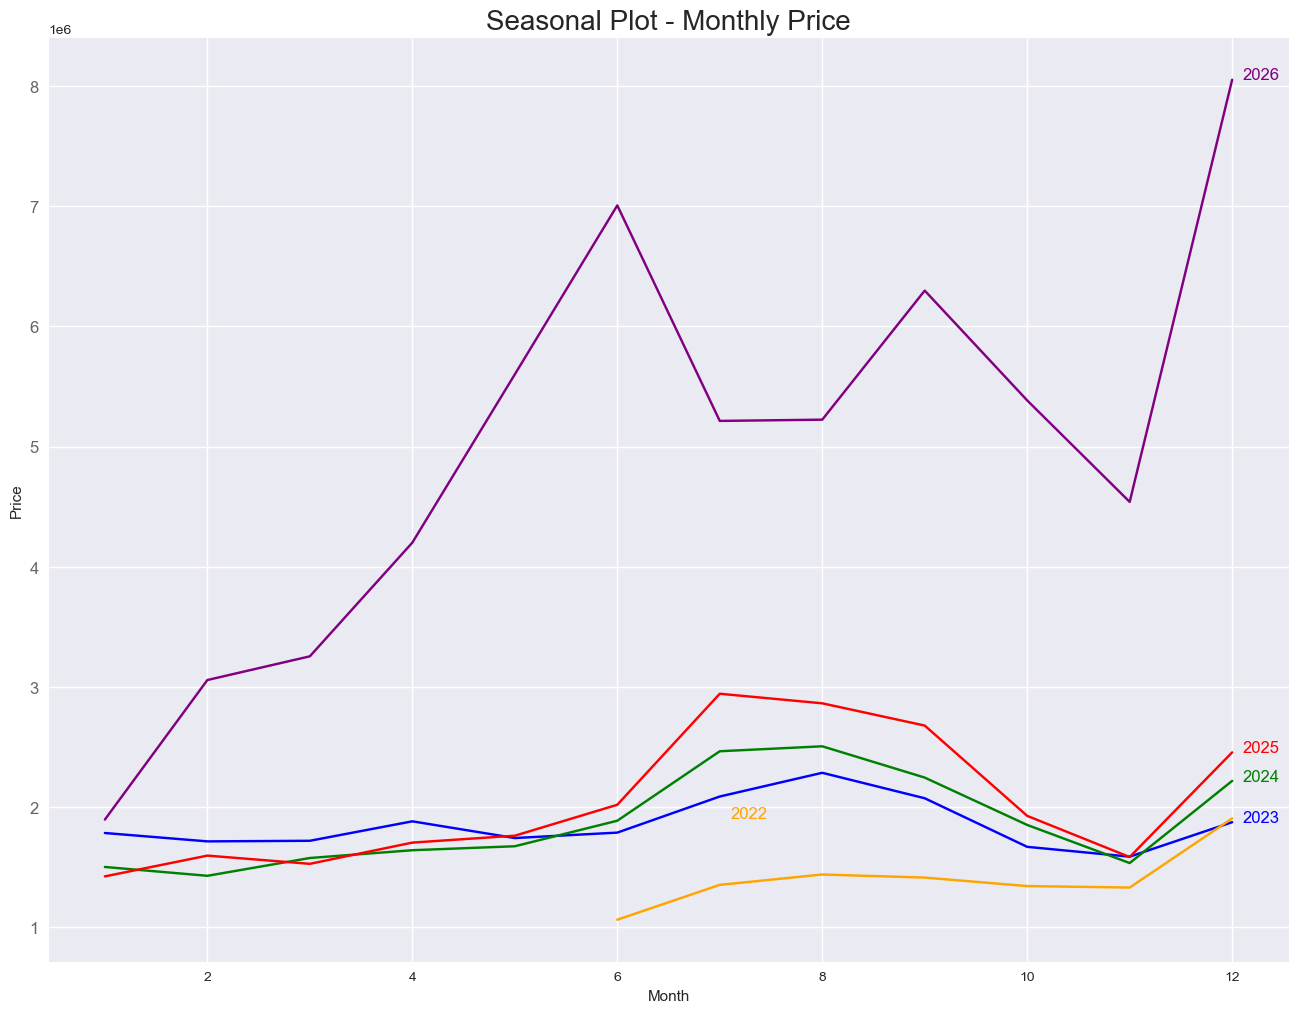

In [35]:
# Defining colors palette
np.random.seed(42)
df_plot = df[['month', 'year', 'price']].dropna().groupby(['month', 'year']).mean()[['price']].reset_index()
years = df_plot['year'].unique()
colors = ['blue', 'green', 'red', 'purple', 'orange', 'cyan', 'magenta', 'yellow', 'brown', 'black']

# Plotting
plt.figure(figsize=(16,12))
for i, y in enumerate(years):
    if i < len(colors):  # Ensuring we don't exceed the number of available colors
        plt.plot('month', 'price', data=df_plot[df_plot['year'] == y], color=colors[i], label=y)
        if y == 2018:
            plt.text(df_plot.loc[df_plot.year==y, :].shape[0]+0.3, df_plot.loc[df_plot.year==y, 'price'][-1:].values[0], y, fontsize=12, color=colors[i])
        else:
            plt.text(df_plot.loc[df_plot.year==y, :].shape[0]+0.1, df_plot.loc[df_plot.year==y, 'price'][-1:].values[0], y, fontsize=12, color=colors[i])

# Setting labels and titles
plt.gca().set(ylabel= 'price', xlabel = 'Month')
plt.yticks(fontsize=12, alpha=.7)
plt.title("Seasonal Plot - Monthly Price", fontsize=20)
plt.ylabel('Price')
plt.xlabel('Month')
plt.show()

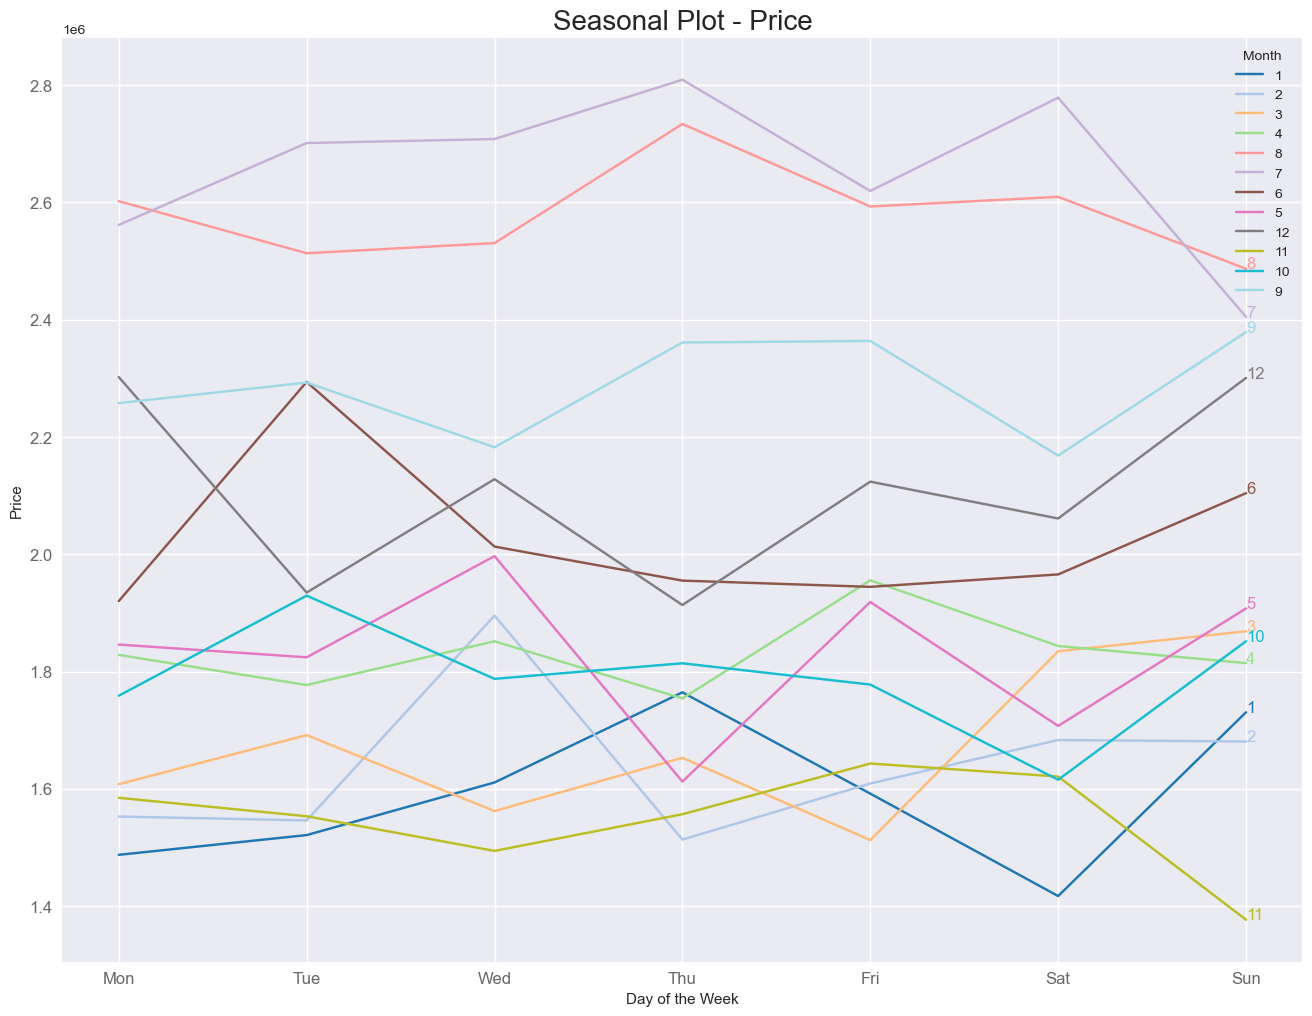

In [36]:
# Preparing the data
np.random.seed(42)
df_plot = df[['month', 'day_str', 'price', 'day']].dropna()
df_plot = df_plot.groupby(['day_str', 'month', 'day']).mean()[['price']].reset_index()
df_plot = df_plot.sort_values(by='day', ascending=True)

# Defining the color palette
months = df_plot['month'].unique()
colors = plt.cm.get_cmap('tab20', len(months)).colors  # Using a colormap from matplotlib

# Plotting
plt.figure(figsize=(16, 12))
for i, month in enumerate(months):
    month_data = df_plot[df_plot['month'] == month]
    plt.plot(month_data['day_str'], month_data['price'], color=colors[i], label=month)
    plt.text(len(month_data['day_str']) - 1, month_data['price'].iloc[-1], month, fontsize=12, color=colors[i])

# Setting labels and titles
plt.xlabel('Day of the Week')
plt.ylabel('Price')
plt.title('Seasonal Plot - Price', fontsize=20)
plt.xticks(fontsize=12, alpha=0.7)
plt.yticks(fontsize=12, alpha=0.7)
plt.legend(title='Month')
plt.show()

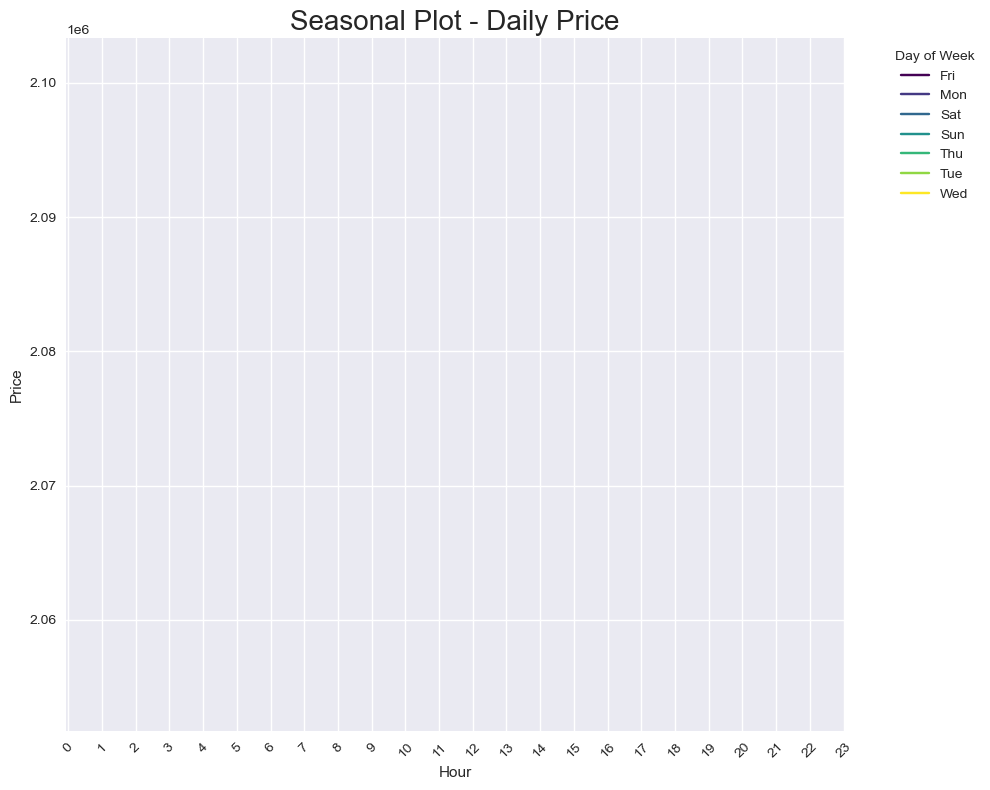

In [37]:
# Preparing the data
df_plot = df[['hour', 'day_str', 'price']].dropna()
df_plot = df_plot.groupby(['hour', 'day_str']).mean().reset_index()

# Plotting using Matplotlib directly
plt.figure(figsize=(10, 8))
days = df_plot['day_str'].unique()
colors = plt.cm.viridis(np.linspace(0, 1, len(days)))

for i, day in enumerate(days):
    day_data = df_plot[df_plot['day_str'] == day]
    plt.plot(day_data['hour'], day_data['price'], label=day, color=colors[i])

# Setting x-axis ticks
plt.xticks(ticks=range(0, 24), labels=[str(i) for i in range(24)], rotation=45)

# Setting labels and titles
plt.title("Seasonal Plot - Daily Price", fontsize=20)
plt.ylabel('Price')
plt.xlabel('Hour')
plt.legend(title='Day of Week', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

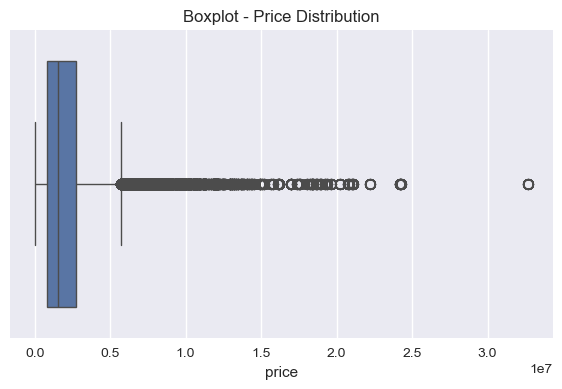

In [39]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='price')
plt.xlabel('price')
plt.title(f'Boxplot - Price Distribution');

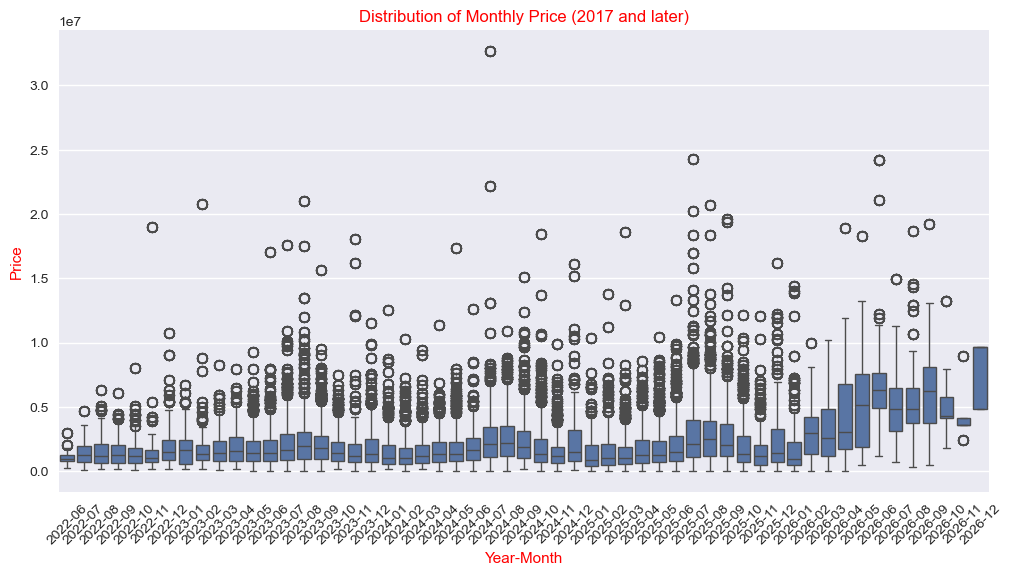

In [41]:
# Extracting year and month features
df['year'] = df.index.year
df['month'] = df.index.month
df['year_month'] = df.index.strftime('%Y-%m')

# Filtering data for years 2017 and later
df_plot = df[df['year'] >= 2017]

# Plotting boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='year_month', y='price', data=df_plot)
plt.title('Distribution of Monthly Price (2017 and later)', color='red')
plt.xlabel('Year-Month', color ='red')
plt.ylabel('Price', color ='red')
plt.xticks(rotation=45)
plt.show()

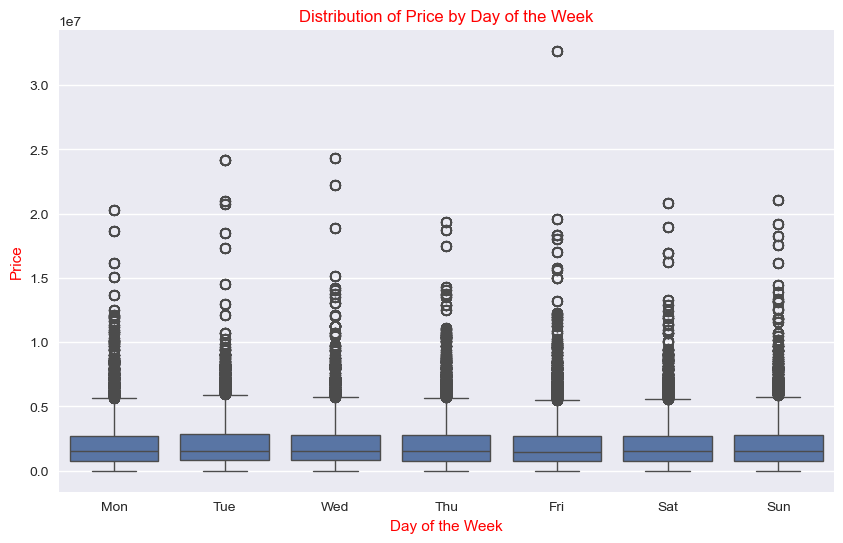

In [42]:
# Sorting the DataFrame by day of the week
df_plot = df[['day_str', 'day', 'price']].sort_values(by='day')

# Plotting boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='day_str', y='price', data=df_plot)
plt.title('Distribution of Price by Day of the Week', color ='red')
plt.xlabel('Day of the Week', color ='red')
plt.ylabel('Price', color='red')
plt.show()

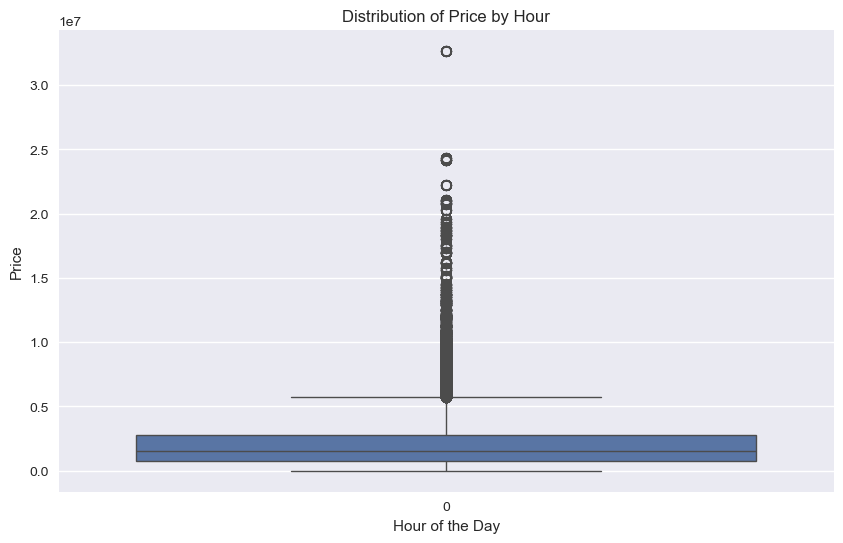

In [43]:
# Plotting boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['hour'], y=df['price'])
plt.title('Distribution of Price by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Price')
plt.show()


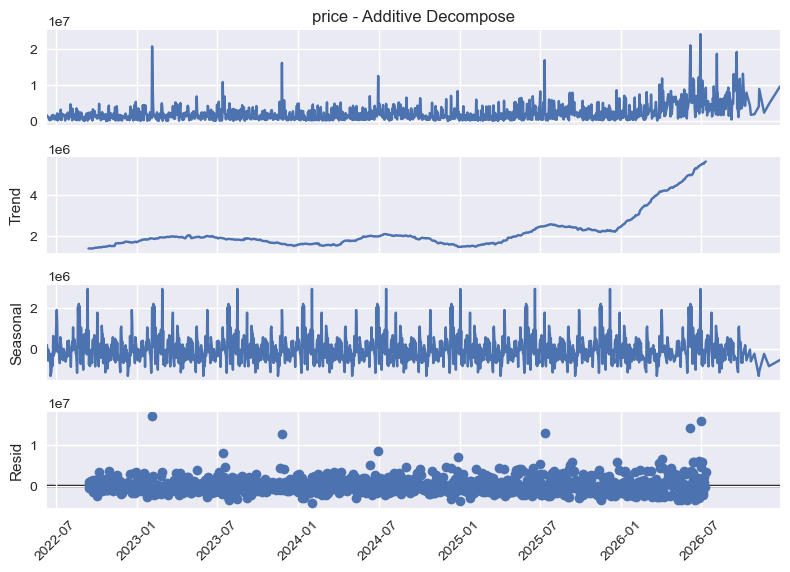

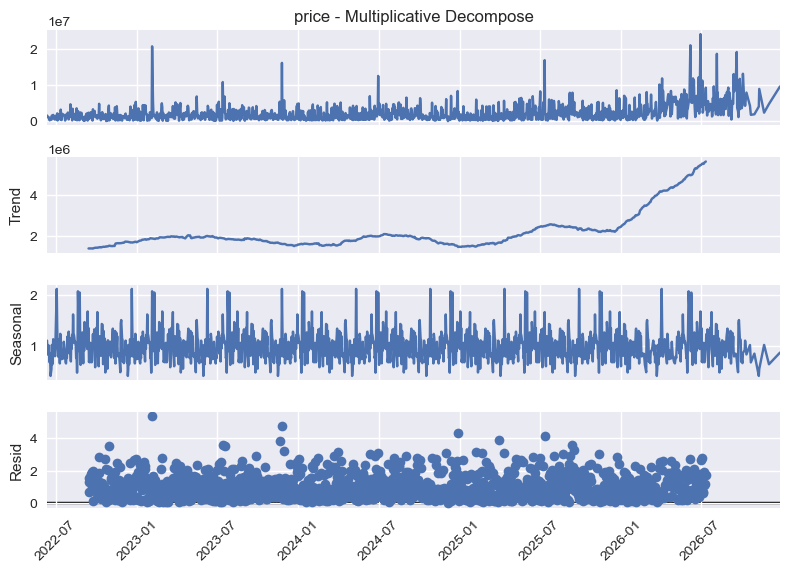

In [55]:
#Importing relevant modeule
from statsmodels.tsa.seasonal import seasonal_decompose

# Filtering data for the year 2017 and reset index
df_plot = df[df['year'] >= 2022].reset_index()

# Removing duplicate Datetime entries and sort by Datetime
df_plot = df_plot.drop_duplicates(subset=['arrival']).sort_values(by='arrival')

# Setting arrival column as index
df_plot = df_plot.set_index('arrival')
df_plot = df_plot[df_plot['price'] > 0]

# Copying the 'price' column for both additive and multiplicative decompose
df_plot['price - Multiplicative Decompose'] = df_plot['price']
df_plot['price - Additive Decompose'] = df_plot['price']

# Performing additive decomposition
result_add = seasonal_decompose(df_plot['price - Additive Decompose'], model='additive', period=24*7)

# Performing multiplicative decomposition
result_mul = seasonal_decompose(df_plot['price - Multiplicative Decompose'], model='multiplicative', period=24*7)

# Plotting additive decomposition
result_add.plot().suptitle('', fontsize=22)
plt.xticks(rotation=45)

# Plotting multiplicative decomposition
result_mul.plot().suptitle('', fontsize=22)
plt.xticks(rotation=45)

# Displaying the plots
plt.show()

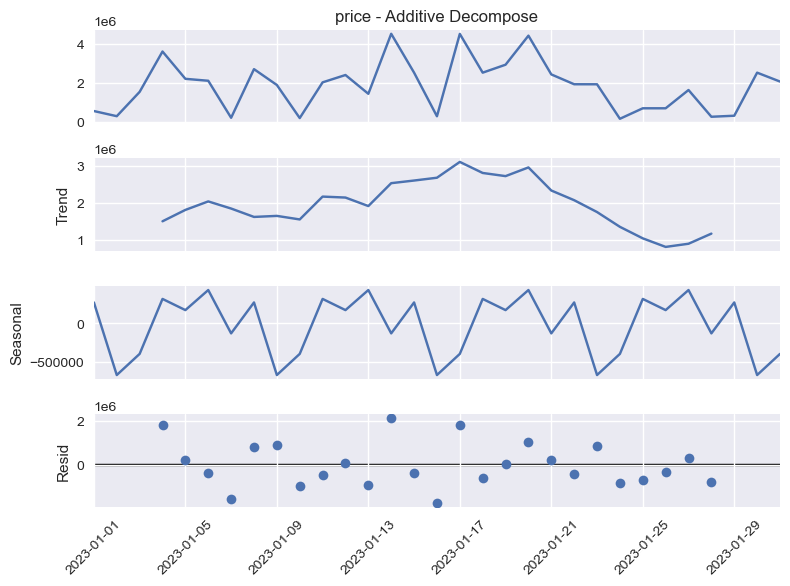

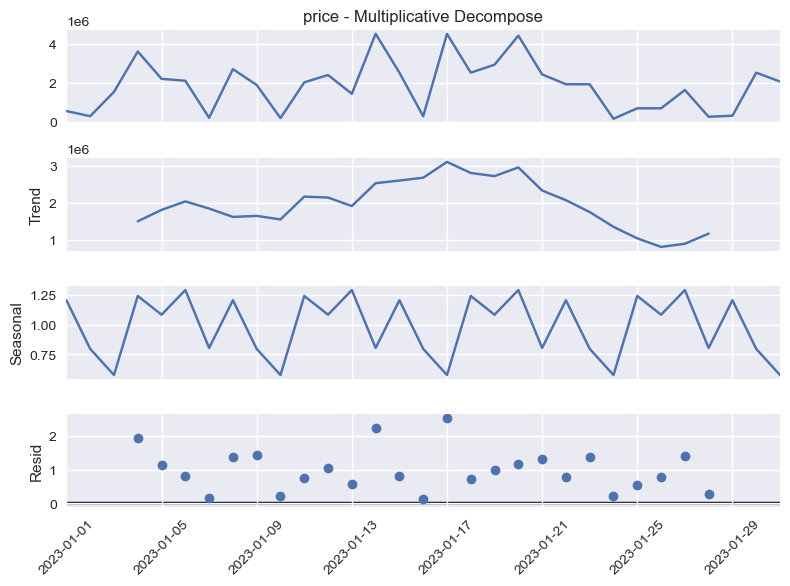

In [67]:
# Filter data for the year 2017 and reset index
df_plot = df[(df['year'] == 2023)].reset_index()

# Filter data for January
df_plot = df_plot[df_plot['month'] == 1]

# Copy the 'price' column for both additive and multiplicative decompose
df_plot['price - Multiplicative Decompose'] = df_plot['price']
df_plot['price - Additive Decompose'] = df_plot['price']

# Remove duplicate Datetime entries and sort by Datetime
df_plot = df_plot.drop_duplicates(subset=['arrival']).sort_values(by='arrival')

# # Set arrival column as index
df_plot = df_plot.set_index('arrival')

# Perform additive decomposition
result_add = seasonal_decompose(df_plot['price - Additive Decompose'], model='additive', period=7)

# Perform multiplicative decomposition
result_mul = seasonal_decompose(df_plot['price - Multiplicative Decompose'], model='multiplicative', period=7)

# Plot additive decomposition
result_add.plot().suptitle('', fontsize=22)
plt.xticks(rotation=45)

# Plot multiplicative decomposition
result_mul.plot().suptitle('', fontsize=22)
plt.xticks(rotation=45)

# Display the plots
plt.show()

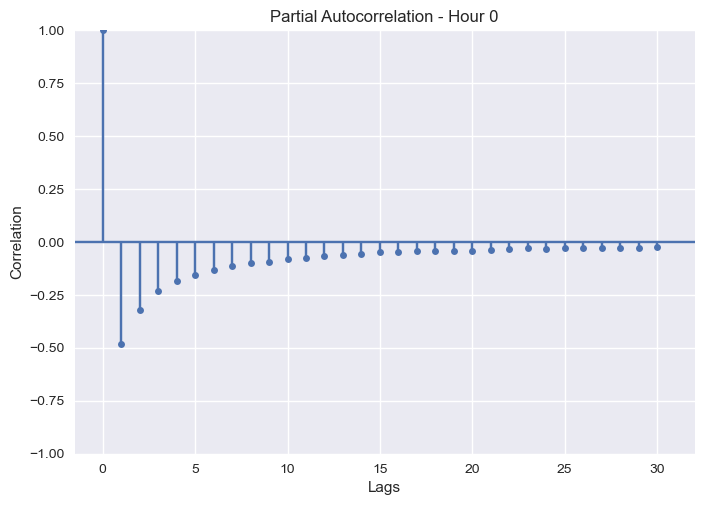

ValueError: Can only compute partial correlations for lags up to 50% of the sample size. The requested nlags 30 must be < 0.

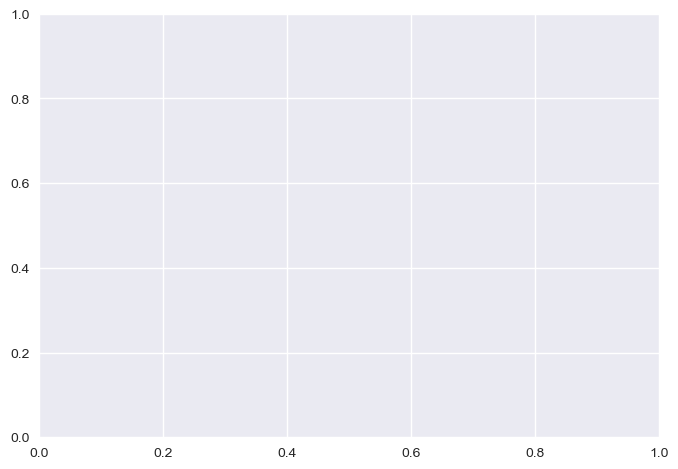

In [68]:
from statsmodels.graphics.tsaplots import plot_pacf

actual = df['price']
hours_of_interest = range(0, 24, 4)

for hour in hours_of_interest:
    hour_data = actual[actual.index.hour == hour].diff().dropna()
    plot_pacf(hour_data, lags=30, alpha=0.01)
    plt.title(f'Partial Autocorrelation - Hour {hour}')
    plt.ylabel('Correlation')
    plt.xlabel('Lags')
    plt.show()


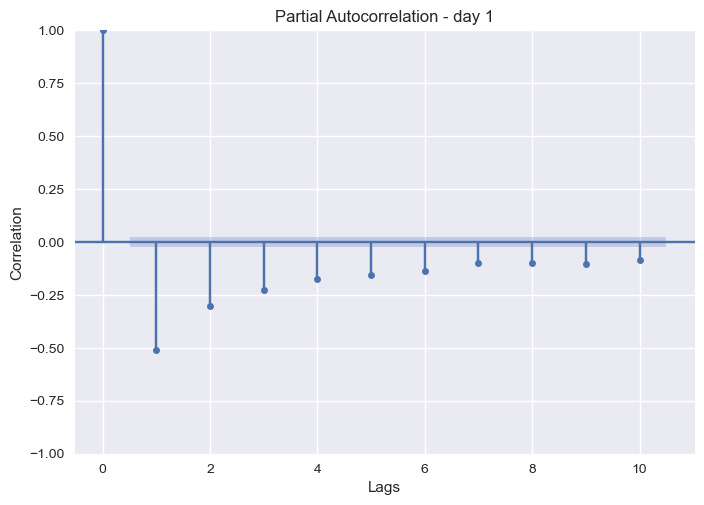

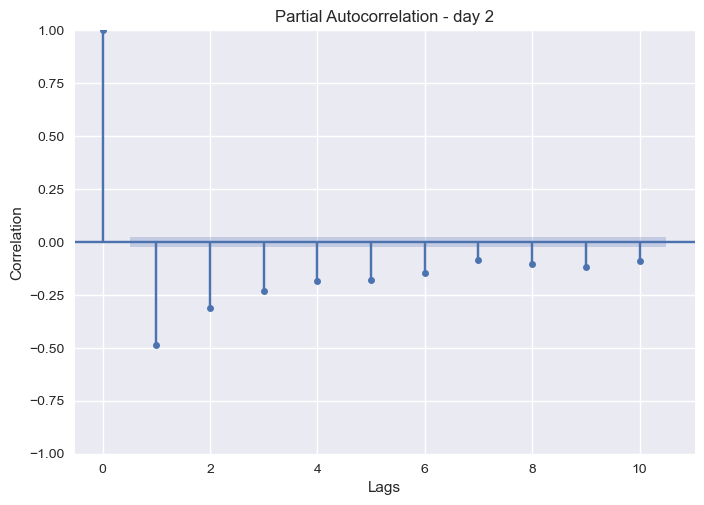

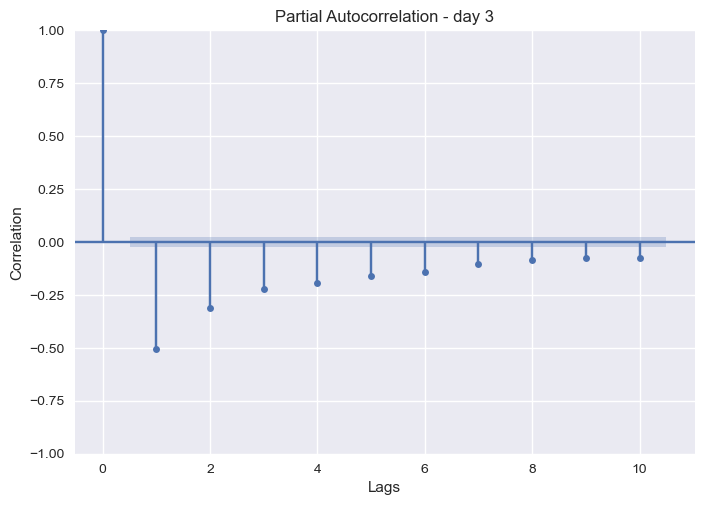

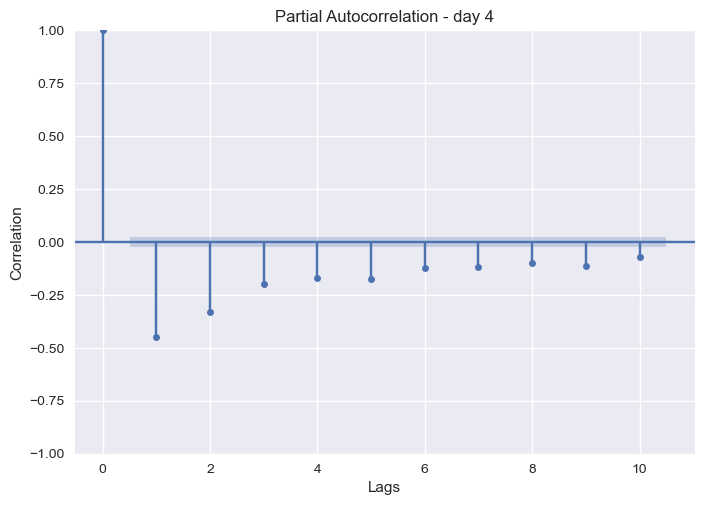

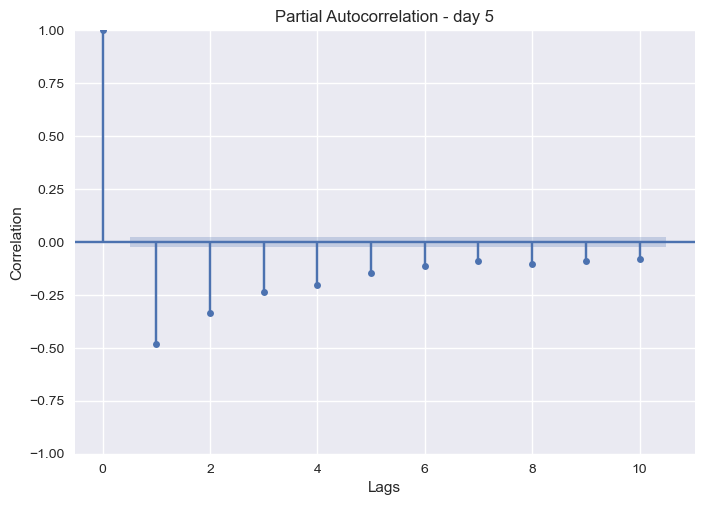

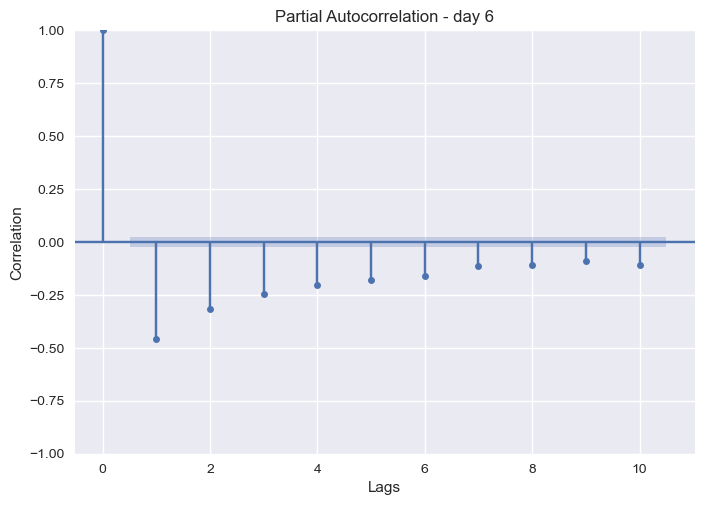

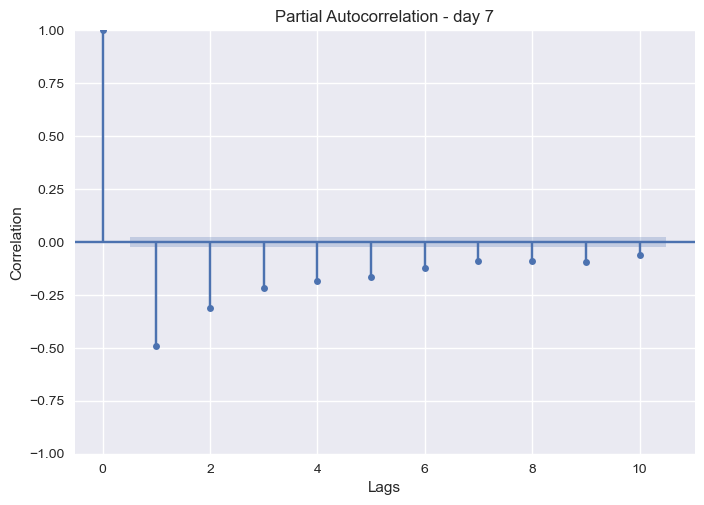

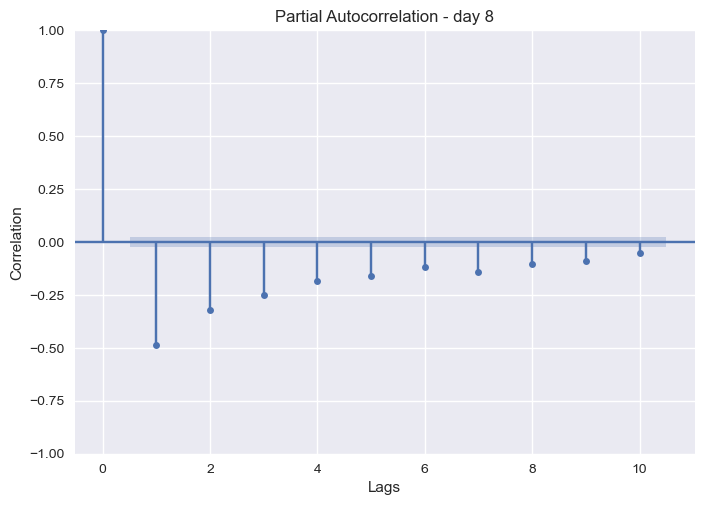

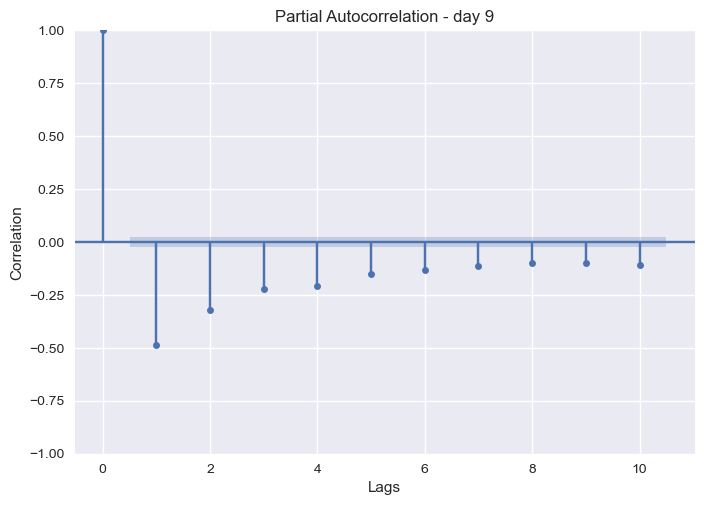

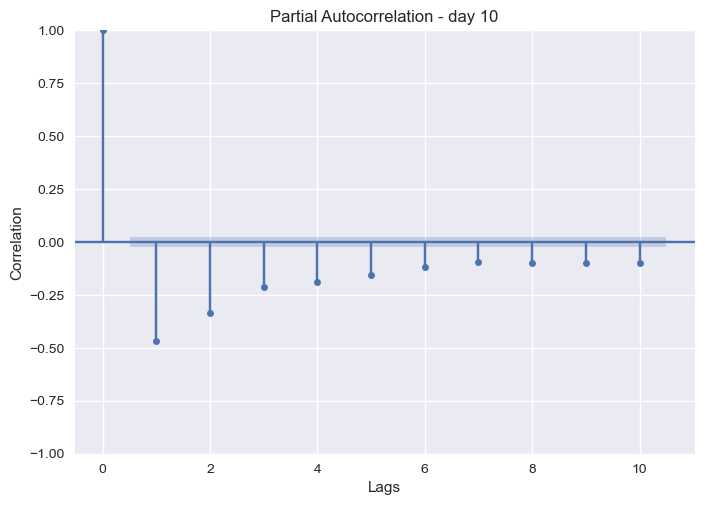

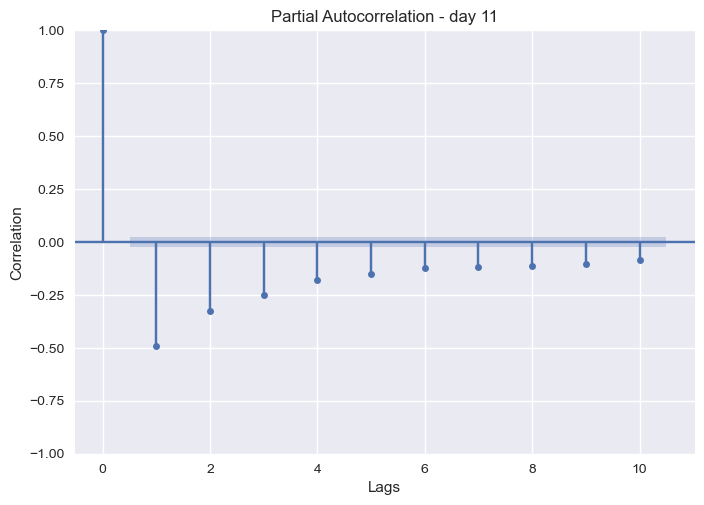

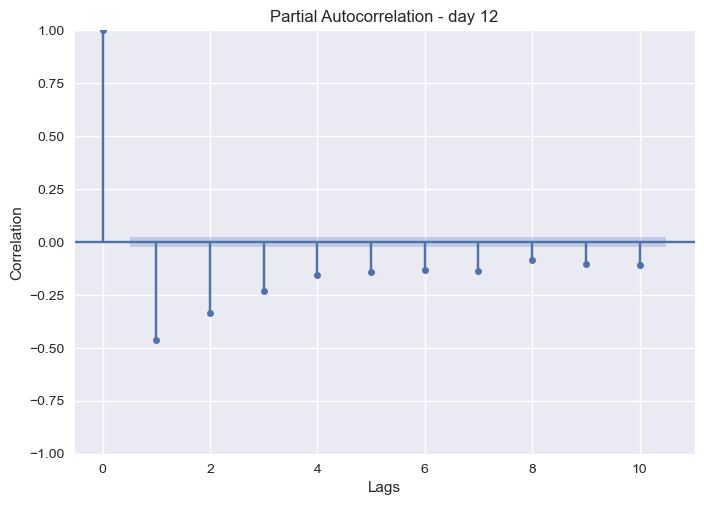

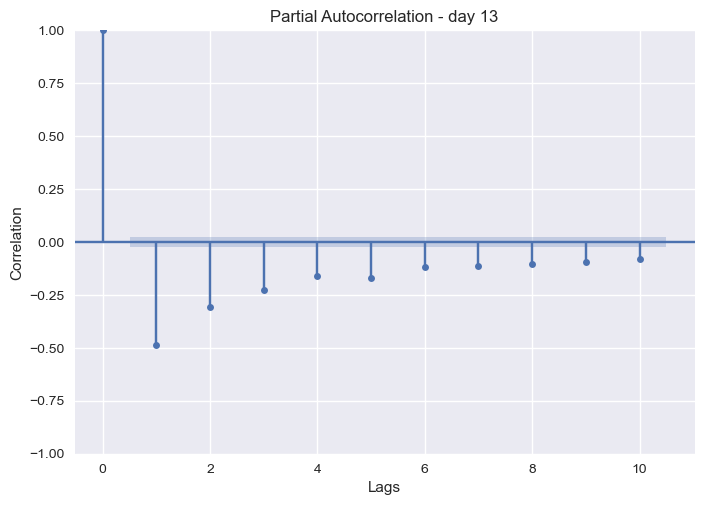

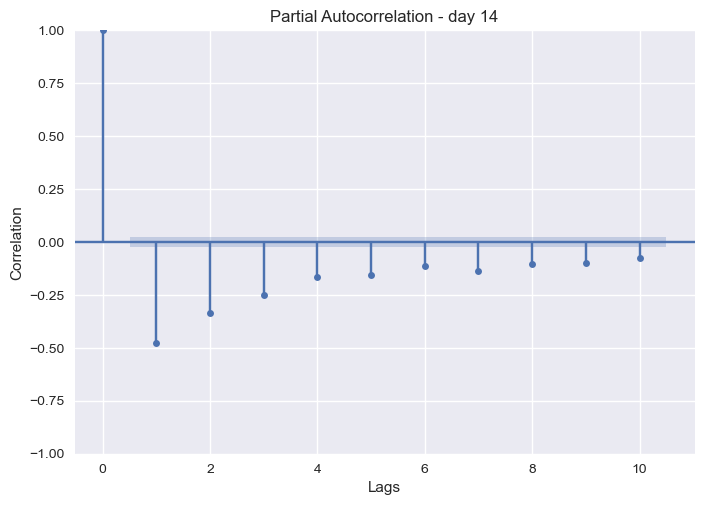

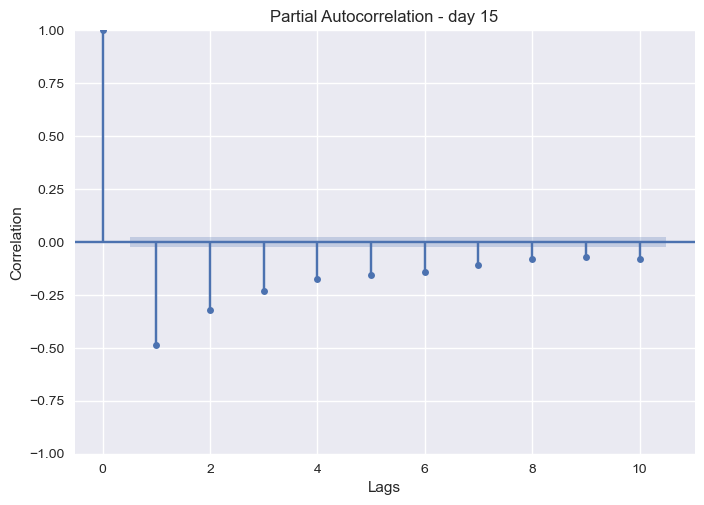

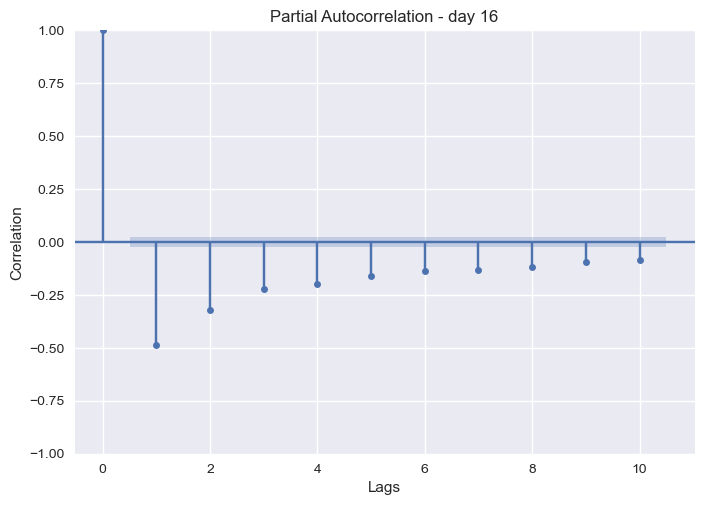

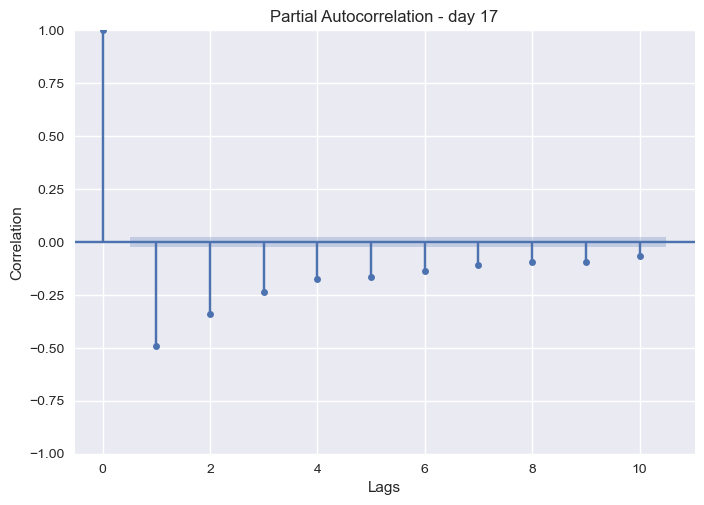

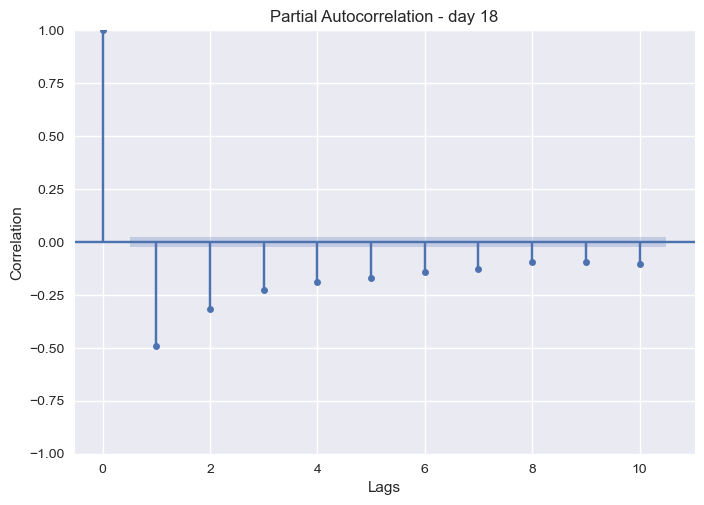

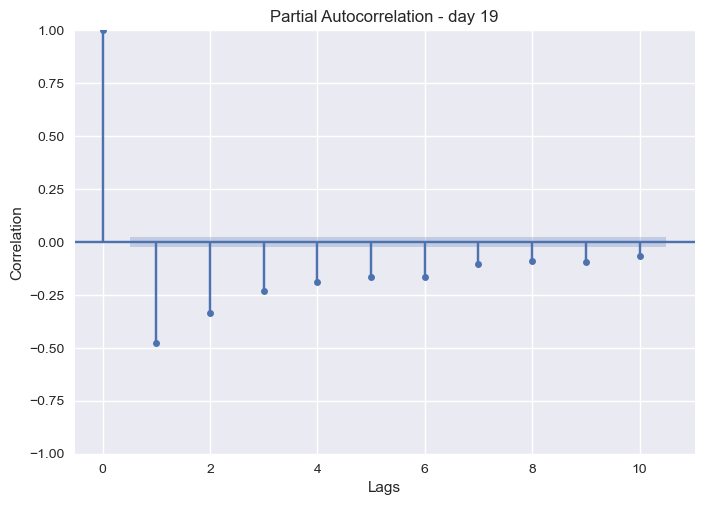

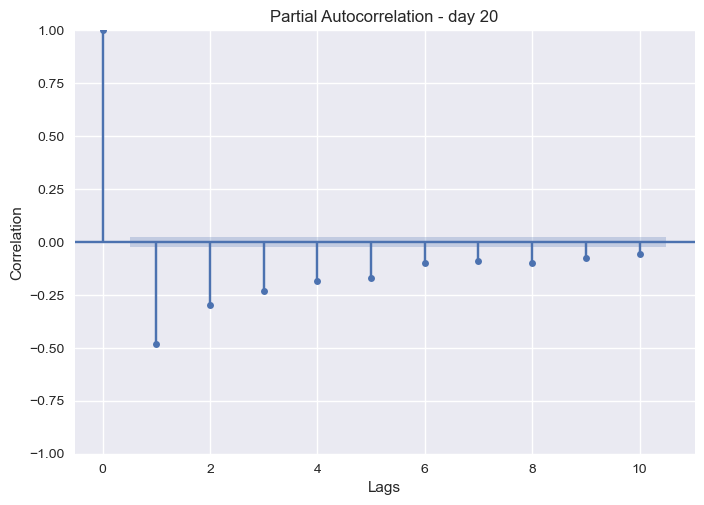

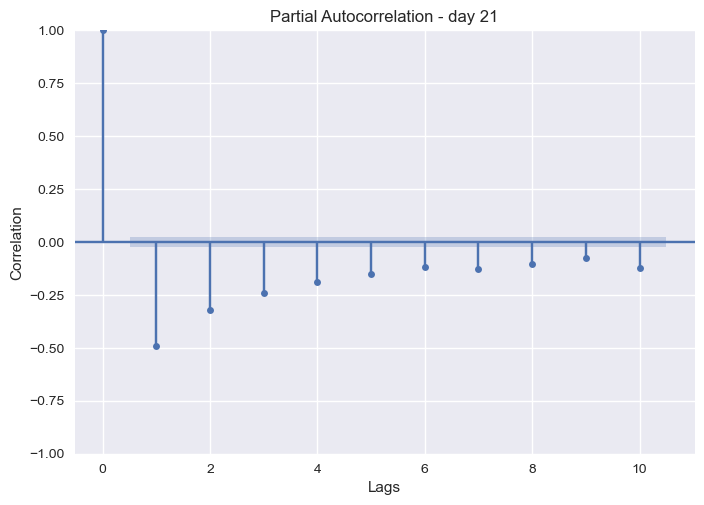

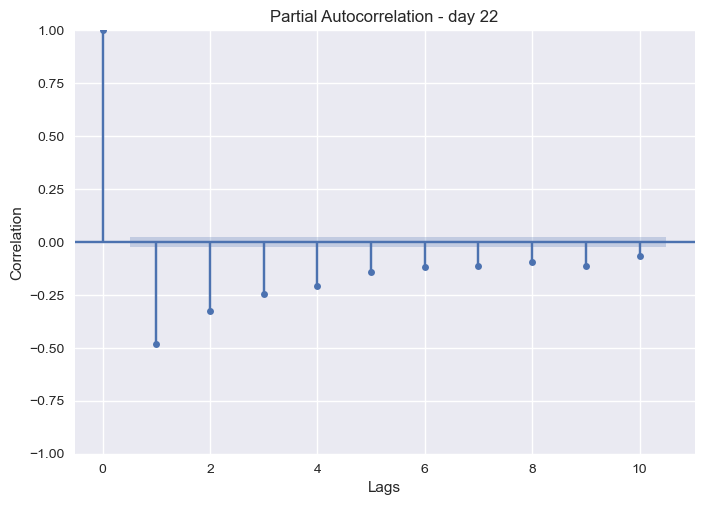

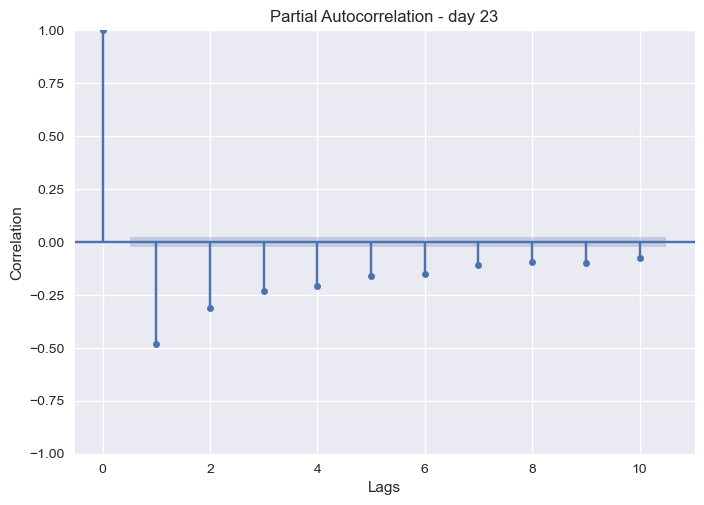

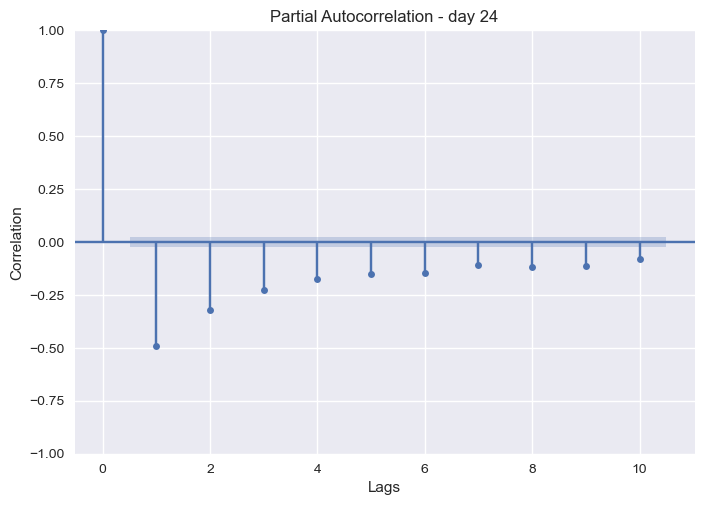

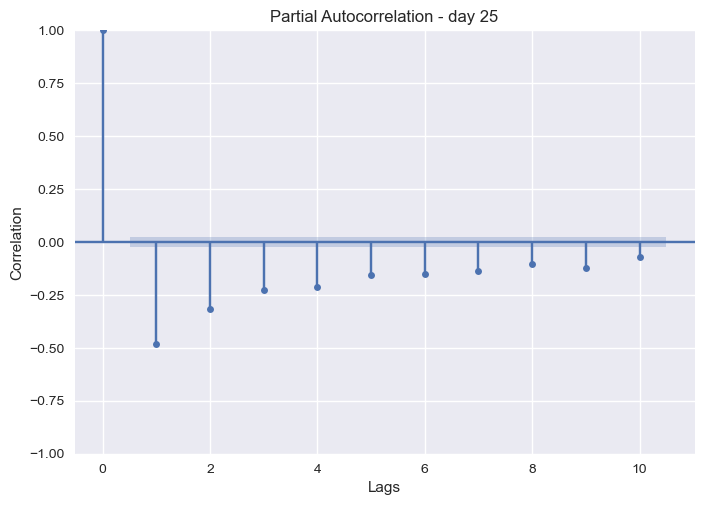

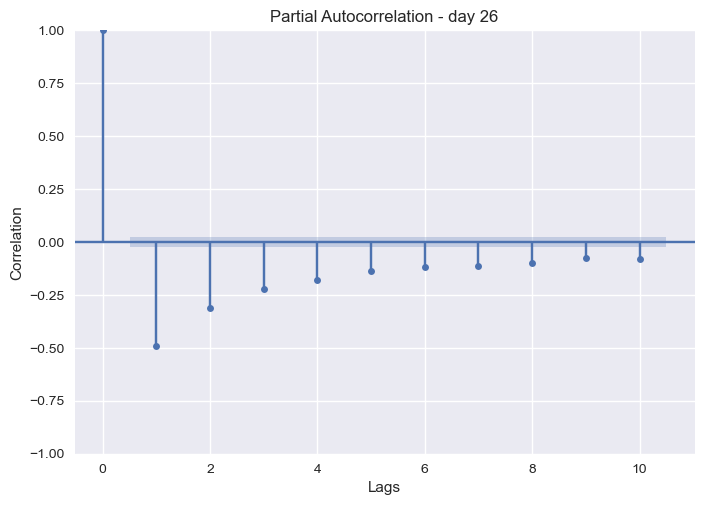

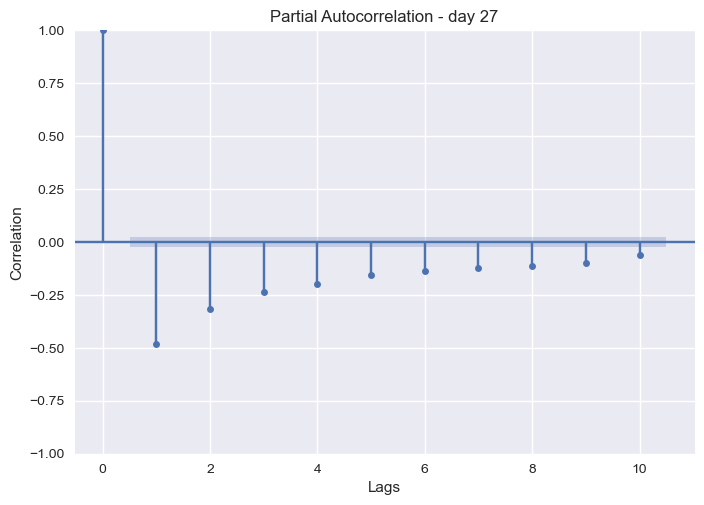

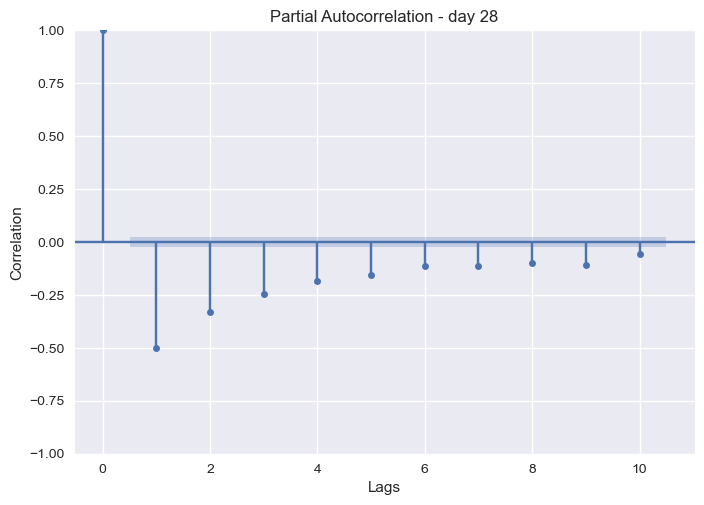

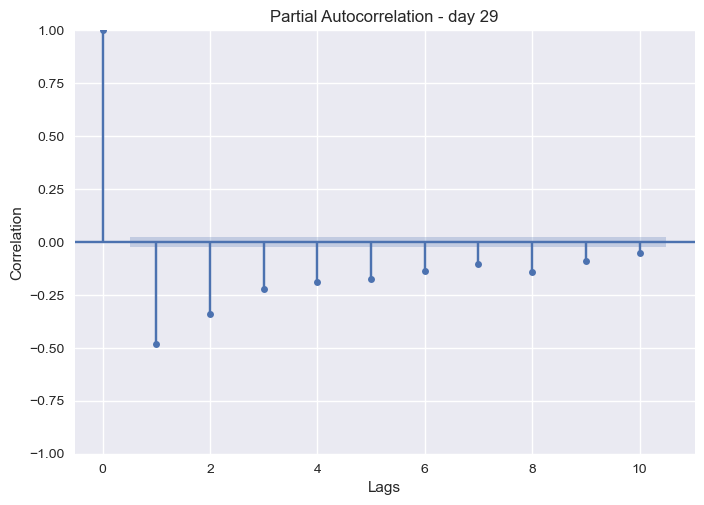

In [74]:
from statsmodels.graphics.tsaplots import plot_pacf

actual = df['price']
days_of_interest = range(1, 30)

for day in days_of_interest:
    day_data = actual[actual.index.day == day].diff().dropna()
    plot_pacf(day_data, lags=10, alpha=0.01)
    plt.title(f'Partial Autocorrelation - day {day}')
    plt.ylabel('Correlation')
    plt.xlabel('Lags')
    plt.show()


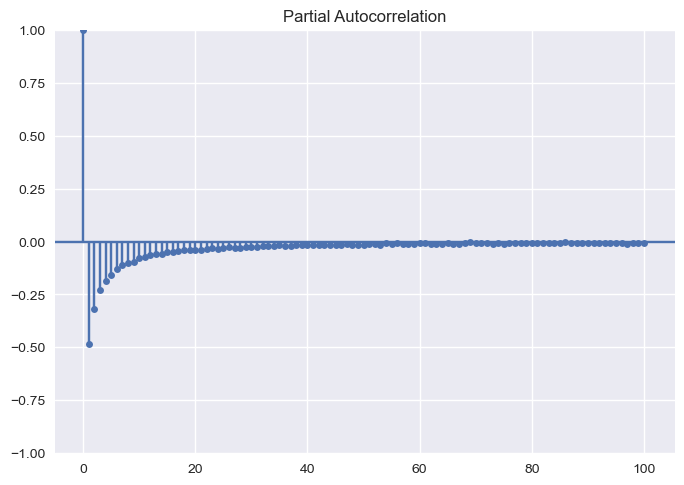

In [77]:
plot_pacf(actual.diff().dropna(), lags=100, method='ywm')
plt.show()

In [ ]:
grid_df = pd.read_pickle(processed_data_dir+'grid_part_1.pkl')

# We need only 'id','d','sales'
# to make lags and rollings
grid_df = grid_df[['id','d','sales']]
SHIFT_DAY = 28

# Lags
# with 28 day shift
start_time = time.time()
print('Create lags')

LAG_DAYS = [col for col in range(SHIFT_DAY,SHIFT_DAY+15)]
grid_df = grid_df.assign(**{
        '{}_lag_{}'.format(col, l): grid_df.groupby(['id'])[col].transform(lambda x: x.shift(l))
        for l in LAG_DAYS
        for col in [TARGET]
    })

# Minify lag columns
for col in list(grid_df):
    if 'lag' in col:
        grid_df[col] = grid_df[col].astype(np.float16)

print('%0.2f min: Lags' % ((time.time() - start_time) / 60))

# Rollings
# with 28 day shift
start_time = time.time()
print('Create rolling aggs')

for i in [7,14,30,60,180]:
    print('Rolling period:', i)
    grid_df['rolling_mean_'+str(i)] = grid_df.groupby(['id'])[TARGET].transform(lambda x: x.shift(SHIFT_DAY).rolling(i).mean()).astype(np.float16)
    grid_df['rolling_std_'+str(i)]  = grid_df.groupby(['id'])[TARGET].transform(lambda x: x.shift(SHIFT_DAY).rolling(i).std()).astype(np.float16)

# Rollings
# with sliding shift
for d_shift in [1,7,14]: 
    print('Shifting period:', d_shift)
    for d_window in [7,14,30,60]:
        col_name = 'rolling_mean_tmp_'+str(d_shift)+'_'+str(d_window)
        grid_df[col_name] = grid_df.groupby(['id'])[TARGET].transform(lambda x: x.shift(d_shift).rolling(d_window).mean()).astype(np.float16)
    
    
print('%0.2f min: Lags' % ((time.time() - start_time) / 60))